# Book Recommendation System

The goal is to recommend books to a reader from the ratings of all readers (collaborative filtering): people who liked the same books as you probably like the books you have not read yet. The data is the Book-Crossing dataset (`BX-Book-Ratings.csv`, `BX-Books.csv` and `BX-Users.csv`): 1,149,780 ratings of 271,360 books by 278,858 users.

Reference solution: [Book Recommendation System with Machine Learning](https://amanxai.com/2020/05/23/book-recommendation-system-with-machine-learning/) (Aman Kharwal). Data: [BX-Book-Ratings.csv](https://amanxai.com/wp-content/uploads/2020/05/BX-Book-Ratings.csv), [BX-Books.csv](https://amanxai.com/wp-content/uploads/2020/05/BX-Books.csv) and [BX-Users.csv](https://amanxai.com/wp-content/uploads/2020/05/BX-Users.csv).

The reference keeps the heavy readers and the popular books, builds a book-by-reader rating table filled with zeros, finds the nearest books with the cosine distance (`NearestNeighbors`) and prints the neighbours of a random book. It never measures whether the recommended books are books that readers actually like. This notebook checks the data preparation of the reference and evaluates several item-based variants on ratings that were hidden from the model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Recommendation Systems/book_recommendation_system')

## Data Loading

In [2]:
books = pd.read_csv("BX-Books.csv", sep=";", encoding="latin-1", on_bad_lines="skip")[["ISBN", "Book-Title"]]
books.columns = ["isbn", "title"]
users = pd.read_csv("BX-Users.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
users.columns = ["user", "location", "age"]
ratings = pd.read_csv("BX-Book-Ratings.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
ratings.columns = ["user", "isbn", "rating"]
print(books.shape, users.shape, ratings.shape)

/tmp/ipykernel_79364/3135229657.py:1: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("BX-Books.csv", sep=";", encoding="latin-1", on_bad_lines="skip")[["ISBN", "Book-Title"]]


(271360, 2) (278858, 3) (1149780, 3)


## Data Cleaning

The rating column has two kinds of rows: explicit ratings from 1 to 10, and zeros, which mean that the reader interacted with the book without giving a rating (an implicit signal). The same book can also exist under several ISBNs (editions), and the reference joins the tables on the title, so the same is done here: a reader who rated two editions of a book keeps the higher rating.

In [3]:
print("share of zeros:", round((ratings["rating"] == 0).mean(), 3), "| explicit ratings:", (ratings["rating"] > 0).sum())
print("ratings whose ISBN is not in the book table:", (~ratings["isbn"].isin(books["isbn"])).sum())

ratings = ratings.merge(books.drop_duplicates("isbn"), on="isbn").groupby(["user", "title"], as_index=False)["rating"].max()
ratings.shape

share of zeros: 0.623 | explicit ratings: 433671
ratings whose ISBN is not in the book table: 118644


(1026358, 3)

## Exploratory Data Analysis

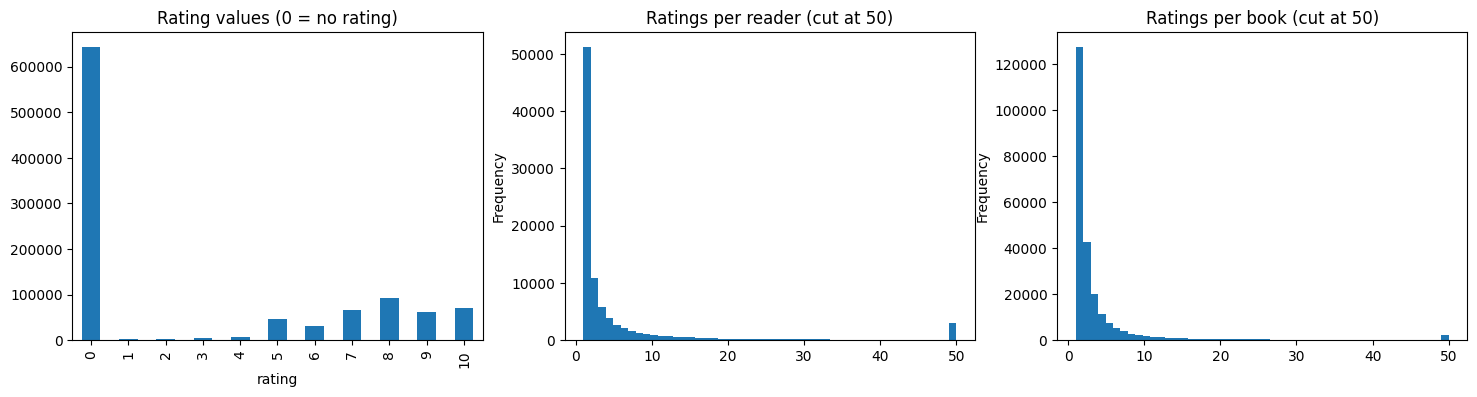

readers: 92106 | books: 241071 | filled share of the table: 0.00462%


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Rating values (0 = no rating)")
ratings.groupby("user").size().clip(upper=50).plot(kind="hist", bins=50, ax=axes[1], title="Ratings per reader (cut at 50)")
ratings.groupby("title").size().clip(upper=50).plot(kind="hist", bins=50, ax=axes[2], title="Ratings per book (cut at 50)")
plt.show()

print("readers:", ratings["user"].nunique(), "| books:", ratings["title"].nunique(), "| filled share of the table:", f"{len(ratings) / (ratings['user'].nunique() * ratings['title'].nunique()):.5%}")

The table of readers and books is almost empty (0.005% of the cells are filled). 62% of the rows are zeros. Among the explicit ratings, high values dominate: most ratings are 7 or more, so a rating of 8 is an ordinary rating and not an enthusiastic one. Two thirds of the readers (67%) and 71% of the books have only one or two ratings, which is why the reference keeps only the heavy readers and the popular books.

## Reference Reproduction

The reference wants "users with less than 200 ratings and books with less than 100 ratings" removed. Its second filter, however, is written on the values of the rating column (`counts = ratings['bookRating'].value_counts()`), not on the books, so it counts how many times each value from 0 to 10 appears and keeps every value. The number of rows removed by this step shows it.

In [5]:
raw = pd.read_csv("BX-Book-Ratings.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
raw.columns = ["user", "isbn", "rating"]

user_counts = raw["user"].value_counts()
heavy = raw[raw["user"].isin(user_counts[user_counts >= 200].index)]

value_counts = heavy["rating"].value_counts()
after_second_filter = heavy[heavy["rating"].isin(value_counts[value_counts >= 100].index)]
print("rows after the filter on users:", len(heavy), "| rows removed by the second filter (on rating values):", len(heavy) - len(after_second_filter))

rows after the filter on users: 527556 | rows removed by the second filter (on rating values): 0


Then the reference keeps the books with at least 50 ratings, keeps the readers from the USA and Canada, builds the book-by-reader table with the missing values replaced by 0 and fits a nearest-neighbour model with the cosine distance. The neighbours of the most rated book of this table are shown.

In [6]:
titled = heavy.merge(books.drop_duplicates("isbn"), on="isbn")
titled = titled[titled.groupby("title")["title"].transform("size") >= 50]
titled = titled.merge(users, on="user")
titled = titled[titled["location"].str.contains("usa|canada", na=False)].drop_duplicates(["user", "title"])

table = titled.pivot(index="title", columns="user", values="rating").fillna(0)
reference_model = NearestNeighbors(metric="cosine", algorithm="brute").fit(csr_matrix(table.values))

query = titled["title"].value_counts().index[0]
distances, neighbours = reference_model.kneighbors(table.loc[[query]].values, n_neighbors=6)
print("table:", table.shape, "| query:", query)
table.index[neighbours[0][1:]].tolist()

table: (746, 734) | query: Wild Animus


['Pay It Forward',
 'At Home in Mitford (The Mitford Years)',
 'The Reader',
 'Cujo',
 'Back Roads']

The result depends on many zeros that mean "not rated" and on a table of only a few hundred books, and there is no way to say whether the neighbours are good recommendations. In the next part the quality is measured.

## Feature Engineering

To measure quality, 20% of the explicit ratings of readers with at least 5 ratings are hidden from the model (the test ratings). A recommender that knows the other ratings of a reader has to find, among the books the reader has not read, the books the reader liked (rating of 8 or more) in the hidden part. The catalogue is made of the books with at least 20 interactions in the training part (ratings and zeros), and every model recommends from the same catalogue.

In [7]:
rng = np.random.default_rng(42)
explicit = ratings["rating"] > 0
eligible = ratings[explicit].groupby("user").size()
eligible = eligible[eligible >= 5].index

is_test = explicit & ratings["user"].isin(eligible) & (rng.random(len(ratings)) < 0.2)
train, test = ratings[~is_test], ratings[is_test]

counts = train.groupby("title").size()
catalogue = pd.Index(counts[counts >= 20].index)
train = train[train["title"].isin(catalogue)]
reader_index = pd.Index(train["user"].unique())
print("catalogue:", len(catalogue), "books | training rows:", len(train), "| test ratings:", len(test))

catalogue: 7107 books | training rows: 403365 | test ratings: 60248


In [8]:
rows, cols = reader_index.get_indexer(train["user"]), catalogue.get_indexer(train["title"])
shape = (len(reader_index), len(catalogue))

matrices = {
    "ratings": csr_matrix((train["rating"].astype("float32"), (rows, cols)), shape=shape),
    "explicit, binary": csr_matrix(((train["rating"] > 0).astype("float32"), (rows, cols)), shape=shape),
    "explicit + zeros, binary": csr_matrix((np.ones(len(train), dtype="float32"), (rows, cols)), shape=shape),
}
matrices["ratings"].eliminate_zeros(); matrices["explicit, binary"].eliminate_zeros()

liked = test[(test["rating"] >= 8) & test["title"].isin(catalogue) & test["user"].isin(reader_index)]
evaluated = rng.choice(liked["user"].unique(), size=3000, replace=False)
eval_rows = reader_index.get_indexer(evaluated)

liked = liked[liked["user"].isin(evaluated)]
liked_matrix = csr_matrix((np.ones(len(liked)), (pd.Index(evaluated).get_indexer(liked["user"]), catalogue.get_indexer(liked["title"]))),
                          shape=(len(evaluated), len(catalogue))).toarray() > 0
seen = matrices["explicit + zeros, binary"][eval_rows].toarray() > 0
print("evaluated readers:", len(evaluated), "| liked hidden books per reader:", round(liked_matrix.sum(axis=1).mean(), 2))

evaluated readers: 3000 | liked hidden books per reader: 2.54


## Model Training

The item-based model of the reference (books that are rated by the same readers are similar) is written with the cosine similarity between all pairs of books. A reader's score for a book is the sum of the similarities between that book and the books the reader has already rated (weighted by the rating in the first variant). Four ways to build the readers-by-books table are compared, together with a baseline that recommends the most popular books to everybody:

- **ratings:** the explicit ratings, as in the reference (missing values are zeros).
- **explicit, binary:** only whether the reader rated the book.
- **explicit + zeros, binary:** every interaction counts, including the zeros that mean "read but not rated".
- **popularity:** the books with the most interactions, the same list for everyone.

In [9]:
def top_ten(scores):
    scores = np.where(seen, -np.inf, scores)
    return np.argsort(-scores, axis=1)[:, :10]

def item_scores(matrix):
    similarity = cosine_similarity(matrix.T)
    np.fill_diagonal(similarity, 0)
    return matrix[eval_rows] @ similarity, similarity

popularity = np.tile(np.asarray(matrices["explicit + zeros, binary"].sum(axis=0)).ravel(), (len(evaluated), 1))

similarities = {}
recommendations = {"popularity": top_ten(popularity)}
for name, matrix in matrices.items():
    scores, similarities[name] = item_scores(matrix)
    recommendations[name] = top_ten(scores)

## Evaluation

In [10]:
def metrics(top):
    hits = np.take_along_axis(liked_matrix, top, axis=1)
    return {"hit rate@10": (hits.sum(axis=1) > 0).mean(), "recall@10": (hits.sum(axis=1) / liked_matrix.sum(axis=1)).mean(),
            "precision@10": hits.mean(), "catalogue coverage": len(np.unique(top)) / len(catalogue)}

random_top = np.argsort(-np.where(seen, -np.inf, rng.random(seen.shape)), axis=1)[:, :10]
recommendations["random"] = random_top

pd.DataFrame({name: metrics(top) for name, top in recommendations.items()}).T.round(4)

,hit rate@10,recall@10,precision@10,catalogue coverage
popularity,0.0590,0.0276,0.0065,0.0065
ratings,0.1037,0.0602,0.0140,0.5578
"explicit, binary",0.1017,0.0595,0.0139,0.5461
"explicit + zeros, binary",0.1617,0.0955,0.0203,0.4117
random,0.0053,0.0027,0.0005,0.9852


In [11]:
query = next(t for t in ["Harry Potter and the Sorcerer's Stone (Book 1)", "The Lovely Bones: A Novel", "The Da Vinci Code"] if t in catalogue)
similarity = similarities["explicit + zeros, binary"]
print(query, "->", catalogue[np.argsort(-similarity[catalogue.get_loc(query)])[:5]].tolist())

Harry Potter and the Sorcerer's Stone (Book 1) -> ['Harry Potter and the Chamber of Secrets (Book 2)', 'Harry Potter and the Prisoner of Azkaban (Book 3)', 'Harry Potter and the Goblet of Fire (Book 4)', 'Harry Potter and the Order of the Phoenix (Book 5)', 'The Silmarillion']


The filter of the reference on rating values removes no row (0 rows), so the announced condition "books with at least 100 ratings" is not applied at that step. The books are filtered later, in a separate step, with a threshold of 50 ratings, so the final table (746 books by 734 readers from the USA and Canada) is reasonable, but its readers and books were selected by the number of ratings including zeros. The book the reference query lands on is "Wild Animus": 2,502 ratings, 77% of them zeros and a mean explicit rating of only 4.4. Its neighbours in a table filled with zeros are the books that the same heavy readers touched, without any sign that they liked them.

The hidden-ratings test gives a clear picture. Recommending the same most popular books to everybody finds a liked hidden book in the ten recommendations of 5.9% of the readers, random recommendations in 0.5%. The item-based collaborative filtering of the reference (ratings as they are, missing values as zeros) reaches 10.4%, and using only the fact that a reader rated a book (binary) gives the same result (10.2%): the rating values add nothing here. The largest gain comes from counting the zeros as interactions, that is the books a reader has read without rating them: the hit rate rises to 16.2% (recall@10 from 6.0% to 9.6%). Two thirds of the interactions in the data are zeros, so ignoring them throws away most of the information about the taste of a reader.

The catalogue coverage shows the effect of personalisation: the popularity baseline draws all its recommendations from only 46 books (0.65% of the catalogue), while the collaborative filtering models recommend 41% to 56% of the catalogue. For the first Harry Potter book, the recommended neighbours are the following books of the series, which is the expected answer.

## Conclusion

**Reference approach.** The reference keeps the readers with at least 200 ratings and the books with at least 50, keeps the readers from the USA and Canada, builds a book-by-reader table with the missing values set to 0, fits a cosine `NearestNeighbors` model and prints the neighbours of a random book. Its intended filter of "books with less than 100 ratings" is written on the values of the rating column and removes 0 rows. The zeros of the table mix two meanings, "not rated" and "read but no rating given", and no evaluation is made.

**Our approach.** 20% of the explicit ratings of the readers with at least 5 ratings were hidden, and the models had to find, among the books a reader had not read, the ones this reader had rated 8 or more (3,000 readers, on average 2.5 hidden liked books each, catalogue of 7,107 books with at least 20 interactions):

| Model | Hit rate@10 | Recall@10 | Precision@10 | Catalogue coverage |
|---|---|---|---|---|
| Random | 0.5% | 0.3% | 0.05% | 98.5% |
| Popularity (same list for everybody) | 5.9% | 2.8% | 0.65% | 0.65% |
| Item-based, ratings (reference idea) | 10.4% | 6.0% | 1.40% | 55.8% |
| Item-based, explicit ratings as binary | 10.2% | 6.0% | 1.39% | 54.6% |
| Item-based, all interactions (with zeros) as binary | 16.2% | 9.6% | 2.03% | 41.2% |

Item-based collaborative filtering is about 1.8 times better than recommending the popular books (hit rate 10.4% against 5.9%), and 2.7 times better when the zeros are used as interactions. The rating values themselves do not matter in this data: only which books a reader interacted with.

**Limitations.** The hit rate is low in absolute terms (16%), because the data is very sparse and a reader has few hidden liked books. Only readers with at least 5 explicit ratings were evaluated, and only books with at least 20 interactions in the training part can be recommended, so new and rare books are out of reach. A book that a reader rated 8 is counted as liked, although 8 is an ordinary rating in this data. The test is offline: it measures whether a model finds books that readers read later, not whether they would have enjoyed a recommendation. Matrix factorisation and user-based methods were not compared.